# Set Up

En este notebook se compara contra la epoca 15, y se toma como referencia los valores del famfold que yo mismo obtuve

Caso:
    Over sampled usando todo el dataset en train

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plt.rc("text", usetex=True)
# plt.rc("font", family="serif")

In [2]:
experiments = [
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]

# One Hot Encoding 15


In [3]:
def get_data(PATH):
    df = pd.read_csv(PATH, index_col=0)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "fam"}, inplace=True)
    df_ref = df[["fam", "famfold"]]
    df_ref.sort_values(by="fam", ascending=False, inplace=True)
    df.drop(columns=["famfold"], inplace=True)
    return df, df_ref


PATH_OH = "SILVER/test_tables_ov/OneHot_15_epochs_test.csv"
df, df_ref = get_data(PATH_OH)

display(df)
display(df_ref)

/tmp/ipykernel_3028996/3551612765.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref.sort_values(by="fam", ascending=False, inplace=True)


,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400,ed
0,16s,0.172197,0.157070,0.161667,0.175516,0.161488,0.152830,0.157428,0.168292,0.150432,999
1,23s,0.238470,0.229374,0.210526,0.238900,0.226427,0.218092,0.216545,0.206449,0.212792,999
2,5s,0.274444,0.270932,0.250319,0.275964,0.260469,0.271124,0.264378,0.283033,0.266354,999
3,RNaseP,0.227642,0.223183,0.195662,0.231432,0.224089,0.211692,0.229750,0.211530,0.206190,999
4,grp1,0.202688,0.177929,0.178124,0.190577,0.187289,0.179173,0.189766,0.180934,0.168627,999
5,srp,0.149521,0.160955,0.153915,0.171547,0.158514,0.159889,0.156458,0.154297,0.147969,999
6,tRNA,0.360006,0.351069,0.411297,0.394705,0.377940,0.366556,0.356754,0.372652,0.345818,999
7,telomerase,0.145224,0.150747,0.097737,0.151355,0.141232,0.118632,0.126115,0.126954,0.112975,999
8,tmRNA,0.199917,0.191287,0.174441,0.194878,0.197681,0.180009,0.199479,0.183526,0.175488,999


,fam,famfold
8,tmRNA,0.167492
7,telomerase,0.114144
6,tRNA,0.465288
5,srp,0.165332
4,grp1,0.166082
3,RNaseP,0.183204
2,5s,0.281220
1,23s,0.209476
0,16s,0.152518


In [4]:
{
    "tmRNA": 0.1674917037517465,
    "telomerase": 0.114144392347629,
    "tRNA": 0.4652880783918064,
    "srp": 0.1653320431133,
    "grp1": 0.166081503499135,
    "RNaseP": 0.1832035462839154,
    "5s": 0.2812198125337743,
    "23s": 0.209475822929747,
    "16s": 0.1525179511457889,
}

{'tmRNA': 0.1674917037517465,
 'telomerase': 0.114144392347629,
 'tRNA': 0.4652880783918064,
 'srp': 0.1653320431133,
 'grp1': 0.166081503499135,
 'RNaseP': 0.1832035462839154,
 '5s': 0.2812198125337743,
 '23s': 0.209475822929747,
 '16s': 0.1525179511457889}

In [5]:
df_ref.set_index("fam")["famfold"].to_dict()

{'tmRNA': 0.1674917037517465,
 'telomerase': 0.114144392347629,
 'tRNA': 0.4652880783918064,
 'srp': 0.1653320431133,
 'grp1': 0.166081503499135,
 'RNaseP': 0.1832035462839154,
 '5s': 0.2812198125337743,
 '23s': 0.209475822929747,
 '16s': 0.1525179511457889}

In [6]:
def normalizar_y_melt(df, rna_llm, experiments):
    rna_llm_series = pd.Series(rna_llm.set_index("fam")["famfold"].to_dict())
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(rna_llm_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    )

    return dfn


def add_metodo_umbral(df: pd.DataFrame) -> pd.DataFrame:
    """Desglosa 'modelo' → ['metodo', 'umbral'] (string)."""
    out = df.copy()
    out[["metodo", "umbral"]] = out["modelo"].str.extract(r"([A-Za-z]+)_(\d+)")
    out["umbral"] = out["umbral"].astype(str)
    return out


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)
dfn = normalizar_y_melt(df, df_ref, experiments)

In [7]:
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})
s

,modelo,rel_f1
0,samples_400,0.973978
1,hc_400,0.978699
2,rnadist_400,1.012282
3,samples_200,1.031288
4,samples_100,1.045739
5,hc_200,1.063178
6,rnadist_200,1.067267
7,hc_100,1.094477
8,rnadist_100,1.117634


In [8]:
PALETTE = {"100": "#2534BB", "200": "#0F690F", "400": "#8E0638"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}


dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados


# plot utils
def strip(ax, df, fam_map, seed=0):
    """Scatter categórico con jitter: color=umbral, marker=método."""
    # jitter
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    # plot
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )


def combined_legend(fig, axes):
    """Leyenda única (métodos + umbrales) sin duplicados."""
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
        if ax.get_legend():
            ax.get_legend().remove()

    color_handles = [
        Line2D([0], [0], marker="D", ls="", color=PALETTE[u], label=u) for u in PALETTE
    ]
    handles += color_handles
    labels += [h.get_label() for h in color_handles]

    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=5, frameon=False)

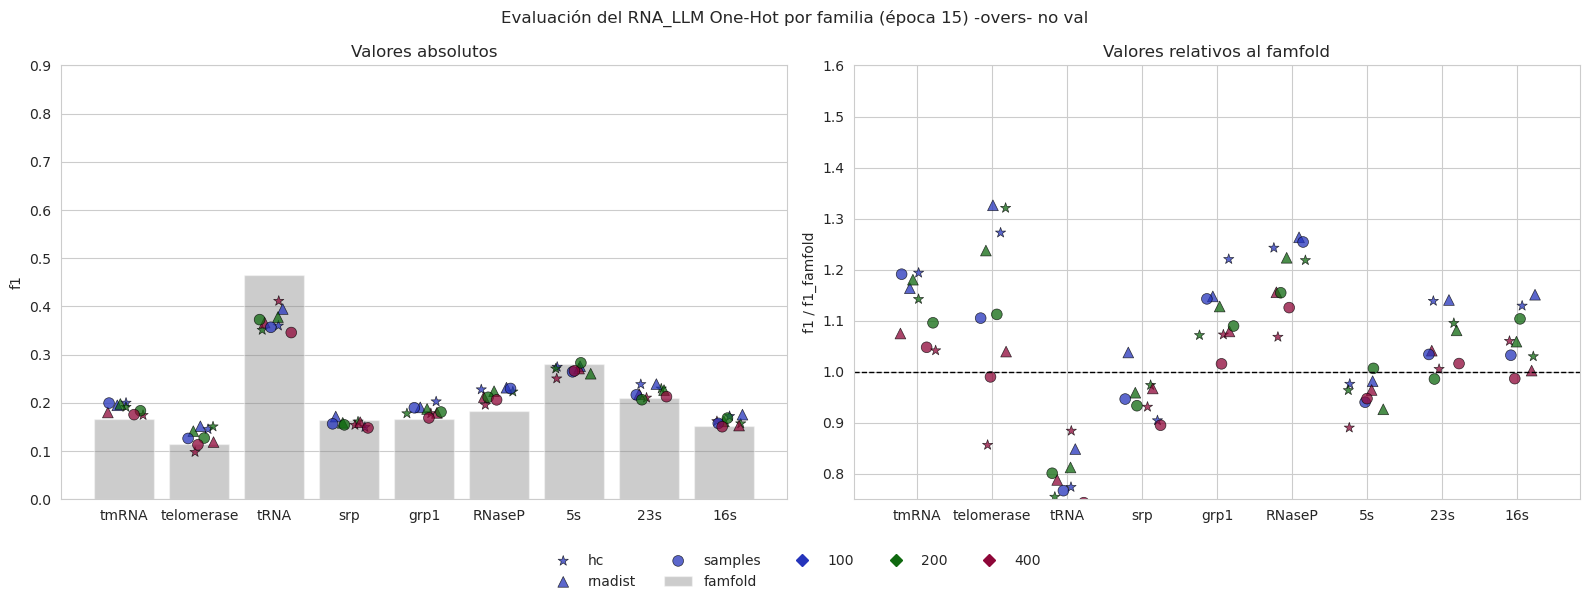

In [9]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.75, 1.6)
axes[1].set_title("Valores relativos al famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("Evaluación del RNA_LLM One-Hot por familia (época 15) -overs- no val")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [10]:
print(dfl)

           fam       modelo        f1   metodo umbral
0          16s       hc_100  0.172197       hc    100
1          23s       hc_100  0.238470       hc    100
2           5s       hc_100  0.274444       hc    100
3       RNaseP       hc_100  0.227642       hc    100
4         grp1       hc_100  0.202688       hc    100
..         ...          ...       ...      ...    ...
76        grp1  samples_400  0.168627  samples    400
77         srp  samples_400  0.147969  samples    400
78        tRNA  samples_400  0.345818  samples    400
79  telomerase  samples_400  0.112975  samples    400
80       tmRNA  samples_400  0.175488  samples    400

[81 rows x 5 columns]


# RiNALMo

In [15]:
PATH_RiNALMo = "SILVER/test_tables_ov/RiNALMo_15_epochs_test.csv"
df, df_ref = get_data(PATH_RiNALMo)

display(df)
display(df_ref)

/tmp/ipykernel_3028996/3551612765.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref.sort_values(by="fam", ascending=False, inplace=True)


,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400,ed
0,16s,0.449643,0.456522,0.507755,0.458332,0.483743,0.471323,0.497973,0.474495,0.524779,999
1,23s,0.555562,0.590465,0.612669,0.543431,0.610788,0.573751,0.576566,0.614452,0.585411,999
2,5s,0.736565,0.742397,0.754717,0.763655,0.759168,0.766680,0.736381,0.731653,0.770101,999
3,RNaseP,0.598952,0.647175,0.664833,0.622862,0.643215,0.625388,0.627342,0.623998,0.629984,999
4,grp1,0.527685,0.554909,0.530461,0.497354,0.537117,0.552484,0.519098,0.532908,0.558371,999
5,srp,0.560204,0.569028,0.560013,0.546887,0.554820,0.581424,0.558890,0.566529,0.580530,999
6,tRNA,0.844458,0.847748,0.876568,0.864766,0.869474,0.874792,0.850126,0.863674,0.884302,999
7,telomerase,0.103562,0.100338,0.082634,0.104234,0.132905,0.097518,0.084793,0.103108,0.079993,999
8,tmRNA,0.553526,0.625165,0.654962,0.579667,0.596219,0.658855,0.608152,0.618772,0.628193,999


,fam,famfold
8,tmRNA,0.620926
7,telomerase,0.090693
6,tRNA,0.835476
5,srp,0.586522
4,grp1,0.474777
3,RNaseP,0.653999
2,5s,0.739421
1,23s,0.573340
0,16s,0.509853


In [16]:
# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)

dfn = normalizar_y_melt(df, df_ref, experiments)
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})
s

,modelo,rel_f1
0,hc_100,0.985948
1,samples_100,0.990623
2,rnadist_100,0.992205
3,samples_400,1.019235
4,hc_200,1.020631
5,hc_400,1.020995
6,samples_200,1.022389
7,rnadist_400,1.028516
8,rnadist_200,1.063102


In [17]:
dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados

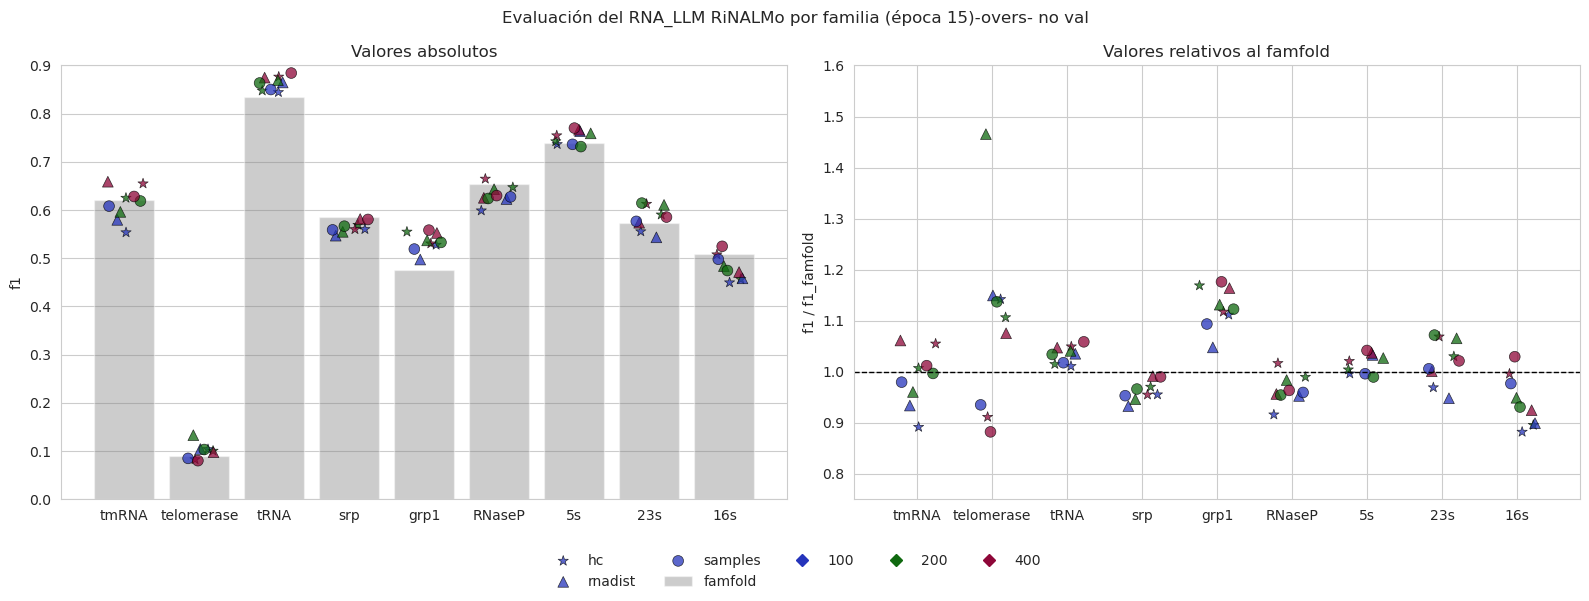

In [18]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.75, 1.6)
axes[1].set_title("Valores relativos al famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("Evaluación del RNA_LLM RiNALMo por familia (época 15)-overs- no val")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()